In [1]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader,Dataset
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [42]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
class shapes_dataset(Dataset):
    """Custom dataset class to make shapes images with colors and labels."""
    def __init__(self, num_samples, transforms=None):
        super(shapes_dataset, self).__init__()
        self.num_samples = num_samples
        self.transforms = transforms
        self.data = []
        self.labels = []
        for _ in range(num_samples):
            shape_type = np.random.choice(['circle', 'square', 'triangle'])
            color = np.random.choice(['red', 'green', 'blue'])
            image = self.generate_image(shape_type, color)
            label = self.get_label(shape_type, color)
            self.data.append(image)
            self.labels.append(label)

    def generate_image(self, shape_type, color):
        """Generates a simple image of a shape with a specific color."""
        image = np.zeros((32, 32, 3), dtype=np.uint8)
        if shape_type == 'circle':
            cv2.circle(image, (16, 16), 10, self.get_color(color), -1)
        elif shape_type == 'square':
            cv2.rectangle(image, (6, 6), (26, 26), self.get_color(color), -1)
        elif shape_type == 'triangle':
            points = np.array([[16, 6], [6, 26], [26, 26]], np.int32)
            cv2.fillPoly(image, [points], self.get_color(color))
        return image

    def get_color(self, color):
        """Returns the BGR color code for the given color name."""
        if color == 'red':
            return (0, 0, 255)
        elif color == 'green':
            return (0, 255, 0)
        elif color == 'blue':
            return (255, 0, 0)

    def get_label(self, shape_type, color):
        """Encodes the shape type and color into a single label."""
        shape_labels = {'circle': 0, 'square': 1, 'triangle': 2}
        color_labels = {'red': 0, 'green': 1, 'blue': 2}
        return shape_labels[shape_type] * 3 + color_labels[color]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.tensor(self.data[idx], dtype=torch.float32).permute(2, 0, 1) / 255.0
        if self.transforms:
            image = self.transforms(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)
    

In [4]:
transform = transforms.Compose([
    transforms.RandomRotation(15),
])

In [5]:
dataset = shapes_dataset(1000, transforms=transform)
# split dataset into train and test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) 

/tmp/ipykernel_1913268/680349499.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  plt.imshow(dataset[5][0].T), plt.title(f"Label: {dataset[5][1]}"), plt.axis('off')


(<matplotlib.image.AxesImage at 0x7f95abc4dd30>,
 Text(0.5, 1.0, 'Label: 8'),
 (np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5)))

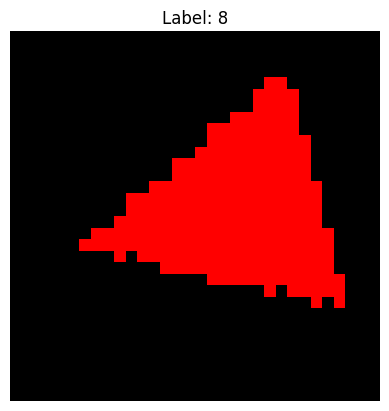

In [6]:
plt.imshow(dataset[5][0].T), plt.title(f"Label: {dataset[5][1]}"), plt.axis('off')

In [19]:
class cnn(nn.Module):
    def __init__(self,input_dim, num_classes):
        super(cnn, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(input_dim, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, num_classes)
        )
    def forward(self, x):
        return self.model(x)

In [20]:
epochs = 20
model = cnn(input_dim=3, num_classes=9)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [21]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:   # rename to val_loader if you want
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

    scheduler.step(val_loss)

    train_loss /= len(train_loader.dataset)
    val_loss /= len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

Epoch 1/20 | train loss: 0.8884 | val loss: 0.0844
Epoch 2/20 | train loss: 0.0219 | val loss: 0.0034
Epoch 3/20 | train loss: 0.0012 | val loss: 0.0007
Epoch 4/20 | train loss: 0.0006 | val loss: 0.0005
Epoch 5/20 | train loss: 0.0004 | val loss: 0.0004
Epoch 6/20 | train loss: 0.0003 | val loss: 0.0003
Epoch 7/20 | train loss: 0.0003 | val loss: 0.0003
Epoch 8/20 | train loss: 0.0002 | val loss: 0.0002
Epoch 9/20 | train loss: 0.0002 | val loss: 0.0002
Epoch 10/20 | train loss: 0.0001 | val loss: 0.0002
Epoch 11/20 | train loss: 0.0001 | val loss: 0.0001
Epoch 12/20 | train loss: 0.0001 | val loss: 0.0001
Epoch 13/20 | train loss: 0.0001 | val loss: 0.0001
Epoch 14/20 | train loss: 0.0001 | val loss: 0.0001
Epoch 15/20 | train loss: 0.0001 | val loss: 0.0001
Epoch 16/20 | train loss: 0.0001 | val loss: 0.0001
Epoch 17/20 | train loss: 0.0000 | val loss: 0.0001
Epoch 18/20 | train loss: 0.0000 | val loss: 0.0000
Epoch 19/20 | train loss: 0.0000 | val loss: 0.0000
Epoch 20/20 | train l

In [24]:
torch.save(model.state_dict(), "models/cnn_shapes.pth")

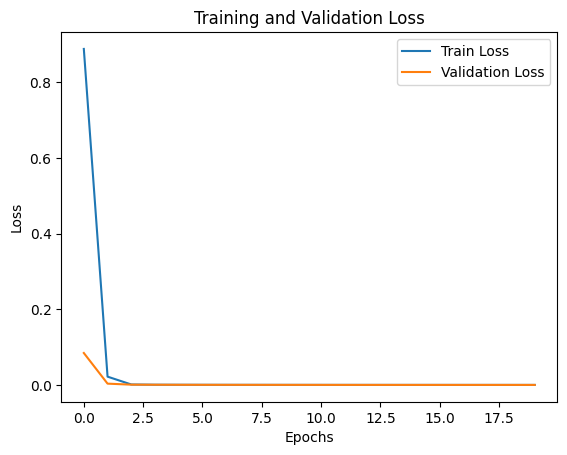

In [22]:
# plot the training and validation
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [28]:
temp_dataset = shapes_dataset(10, transforms=transform)
temp_loader = DataLoader(temp_dataset, batch_size=1, shuffle=False)

In [52]:
for i in range(10):
    image, label = temp_dataset[i]
    image = image.unsqueeze(0)  # Add batch dimension
    model.eval()
    with torch.no_grad():
        output = model(image)
        predicted_label = torch.argmax(output, dim=1).item()
    print(f"True Label: {label.item()}, Predicted Label: {predicted_label}")


[W510 07:25:19.138721565 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.149066578 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.161963909 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.176896794 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.198072452 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.204794075 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.224629159 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.241793821 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.270572603 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.283120941 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:2

True Label: 1, Predicted Label: 1
True Label: 8, Predicted Label: 8
True Label: 2, Predicted Label: 2
True Label: 1, Predicted Label: 1
True Label: 2, Predicted Label: 2
True Label: 3, Predicted Label: 3
True Label: 1, Predicted Label: 1
True Label: 3, Predicted Label: 3
True Label: 6, Predicted Label: 6
True Label: 3, Predicted Label: 3


[W510 07:25:19.350476410 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.358701904 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.381509337 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.395619915 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.431839495 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.442593447 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.453728914 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W510 07:25:19.454404458 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
